## Task 1: Import pandas

In [2]:
import pandas as pd

# Load dataset (replace with actual path or link)
df = pd.read_csv("tips.csv")

# Display dataset
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Task 2: Check shape, columns, types

In [3]:
print(df.shape)
print(df.columns)
print(df.dtypes)
df.info()

(244, 7)
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')
total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


## Task 3: Quick look

In [4]:
df.head()
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Task 4: Indexing & Selection

In [5]:
# First 5 rows, specific columns
df.iloc[:5][['total_bill','tip']]

# Last 3 rows, day & time
df.iloc[-3:][['day','time']]

# Using loc
df.loc[0:10, ['total_bill','sex']]


,total_bill,sex
0,16.99,Female
1,10.34,Male
2,21.01,Male
3,23.68,Male
4,24.59,Female
5,25.29,Male
6,8.77,Male
7,26.88,Male
8,15.04,Male
9,14.78,Male


## Task 5: Filtering

In [6]:
# High bill customers
df[df['total_bill'] > 40]

# By gender
df[df['sex'] == 'Female']

# By time
df[df['time'] == 'Dinner']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## Task 6: Value Counts

In [7]:
df['day'].value_counts(normalize=True)
df['sex'].value_counts(normalize=True)


,proportion
sex,
Male,0.643443
Female,0.356557


## Task 7: Sorting

In [8]:
df.sort_values('total_bill', ascending=False).head()
df.sort_values('tip', ascending=False).head()


,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
23,39.42,7.58,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
141,34.30,6.70,Male,No,Thur,Lunch,6


## Task 8: Missing Values

In [9]:
df.isnull().sum()


,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


## Task 9: Feature Creation

In [10]:
df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100

# Example binning
df['bill_bins'] = pd.cut(df['total_bill'], bins=[0,10,20,40,60], labels=['Low','Medium','High','Very High'])


## Task 10: Grouping, Crosstab, Pivot

In [11]:
df.groupby('sex')['tip'].mean()
df.groupby('day')['total_bill'].mean()

pd.crosstab(df['day'], df['sex'])
pd.pivot_table(df, values='tip', index='day', columns='sex', aggfunc='mean')


sex,Female,Male
day,,
Fri,2.781111,2.693000
Sat,2.801786,3.083898
Sun,3.367222,3.220345
Thur,2.575625,2.980333


## Task 11: Ranking

In [12]:
df['bill_rank'] = df['total_bill'].rank(ascending=False)
df['tip_rank'] = df['tip_percentage'].rank(ascending=False)


## Task 12: Transformations & Cleaning

In [13]:
# Map example
df['time_mapped'] = df['time'].map({'Lunch':0, 'Dinner':1})

# Unique categories
df['day'].unique(), df['day'].nunique()

# Duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# Rename columns
df.rename(columns={'sex':'gender'}, inplace=True)


## Task 13: Visualization

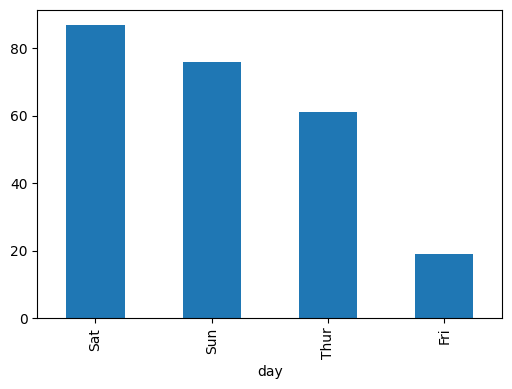

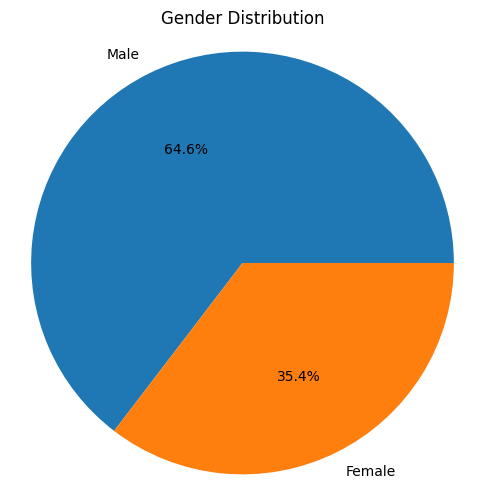

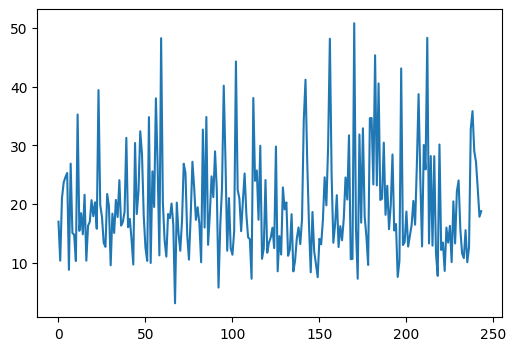

<Figure size 600x400 with 0 Axes>

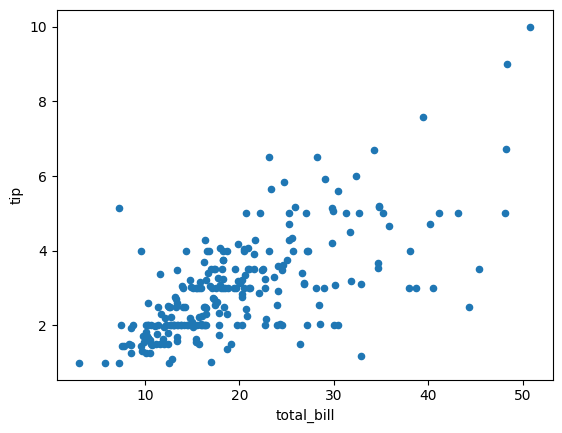

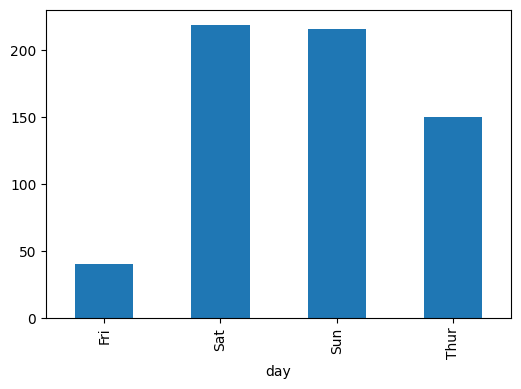

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['day'].value_counts().plot(kind='bar')
plt.show()

plt.figure(figsize=(6,6))
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ylabel='',
    legend=False,
    title='Gender Distribution'
)
plt.axis('equal')
plt.show()

plt.figure(figsize=(6,4))
df['total_bill'].plot(kind='line')
plt.show()

plt.figure(figsize=(6,4))
df.plot.scatter(x='total_bill', y='tip')
plt.show()

plt.figure(figsize=(6,4))
df.groupby('day')['size'].sum().plot(kind='bar', stacked=True)
plt.show()
